# 2.1 数据获取


> **这一节讲什么？**
> 
> 数据是量化交易的原材料。这一节介绍从哪里获取金融数据（yfinance、adata、akshare），以及如何正确读取和初步处理它们。数据质量直接决定策略质量。

## 学习目标
- 使用 yfinance 获取美股/全球数据
- 使用 **adata** / AKShare 获取 A 股数据
- **获取宏观经济数据（利率、10年期美债等）**
- 了解数据字段含义（OHLCV）
- 将数据保存为 CSV 供后续使用

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path #处理文件路径和文件系统操作

# 数据存储路径
DATA_DIR = Path('../datasets')
DATA_DIR.mkdir(exist_ok=True)#"如果文件夹已经存在，也没关系"
print('准备就绪 ✅')

准备就绪 ✅


In [8]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. yfinance — 美股数据

In [9]:
# ===== 单只股票 =====
# ticker = yf.Ticker('AAPL')

# 日线历史数据
# hist = ticker.history(start='2020-01-01', end='2024-01-01')
# print('AAPL 历史数据字段:', hist.columns.tolist())
# print(f'数据量: {len(hist)} 行')
# hist.tail(3)

import yfinance as yf

# 使用 yf.download() 替代 Ticker().history()
hist = yf.download('AAPL', start='2024-01-01', end='2025-01-01', repair=True)
print('AAPL 历史数据字段:', hist.head())
print(f'数据量: {len(hist)} 行')
hist.tail(3)

[*********************100%***********************]  1 of 1 completed

AAPL 历史数据字段: Price            Close        High         Low        Open Repaired?    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL      AAPL
Date                                                                          
2024-01-02  183.562210  186.330874  181.831797  185.055304     False  82488700
2024-01-03  182.187729  183.799489  181.376900  182.158066     False  58414500
2024-01-04  179.873947  181.040733  178.855477  180.111251     False  71983600
2024-01-05  179.152115  180.714432  178.153425  179.953062     False  62379700
2024-01-08  183.483063  183.522623  179.468508  180.051901     False  59144500
数据量: 252 行


Price,Close,High,Low,Open,Repaired?,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2024-12-27,253.967392,257.057664,251.453455,256.193162,False,42355300
2024-12-30,250.598892,251.890642,249.158101,250.628701,False,35557500
2024-12-31,248.830215,251.672059,247.846495,250.837396,False,39480700


In [4]:
# ===== 字段说明 =====
field_desc = {
    'Open':  '开盘价 — 当日第一笔成交价',
    'High':  '最高价 — 当日最高成交价',
    'Low':   '最低价 — 当日最低成交价',
    'Close': '收盘价 — 当日最后成交价（原始）',
    'Volume':'成交量 — 当日总成交股数',
    'Dividends': '分红 — 当日每股分红金额',
    'Stock Splits': '股票拆分倍数（2=一股变两股）'
}
for k, v in field_desc.items():
    if k in hist.columns:
        print(f'  {k:<15}: {v}')

  Open           : 开盘价 — 当日第一笔成交价
  High           : 最高价 — 当日最高成交价
  Low            : 最低价 — 当日最低成交价
  Close          : 收盘价 — 当日最后成交价（原始）
  Volume         : 成交量 — 当日总成交股数
  Dividends      : 分红 — 当日每股分红金额
  Stock Splits   : 股票拆分倍数（2=一股变两股）


normalized后的数据样子：
 Ticker            AAPL       AMZN      GOOGL        MSFT         SPY
Date                                                                
2023-12-01  106.271660  86.282934  90.943258  113.927143   98.747460
2023-12-04  105.265842  84.997756  89.156934  112.293575   98.229105
2023-12-05  107.483087  86.194912  90.343222  113.321773   98.209744
2023-12-06  106.871817  84.809972  89.674216  112.190144   97.813989
2023-12-07  107.955437  86.194912  94.440016  112.844177   98.560337
2023-12-08  108.755638  86.511801  93.102014  113.841977   98.984073
2023-12-11  107.349707  85.613938  91.929520  112.950636   99.369074
2023-12-12  108.199935  86.547010  91.398466  113.887593   99.822919
2023-12-13  110.005962  87.345111  91.432940  113.884555  101.199488
2023-12-14  110.089304  86.511801  90.998413  111.317079  101.524279
2023-12-15  109.789230  88.008242  91.453642  112.777257  101.357106
2023-12-18  108.855677  90.414286  93.660656  113.361323  101.927253
2023-12-19  109

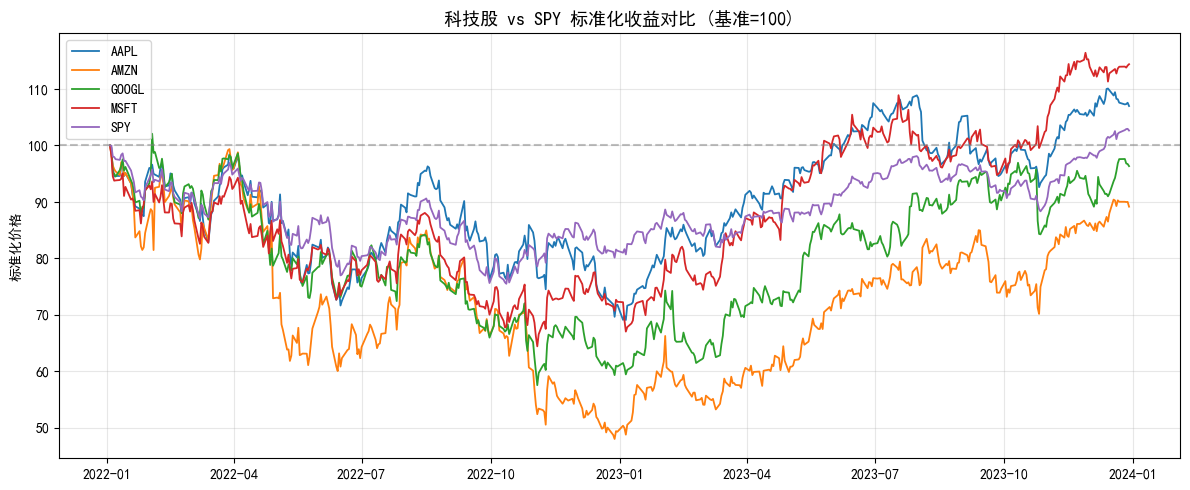

已保存至 ../datasets/sp500_sample.csv
已保存至 ../datasets/sp500_sample_normalized.csv
已保存至 ../datasets/sp500_sample.parquet


Ticker,AAPL,AMZN,GOOGL,MSFT,SPY
Date,,,,,
2022-01-03,177.939728,170.404495,143.802979,322.462341,450.644379
2022-01-04,175.681366,167.522003,143.215820,316.933014,450.493530
2022-01-05,171.008301,164.356995,136.645630,304.766663,441.843018
2022-01-06,168.153580,163.253998,136.618347,302.358429,441.428009
2022-01-07,168.319733,162.554001,135.893829,302.512543,439.682770
2022-01-10,168.339340,161.485992,137.532776,302.734100,439.135681
2022-01-11,171.164703,165.362000,138.590546,303.418121,443.135468
2022-01-12,171.604660,165.207001,140.271149,306.587280,444.333405
2022-01-13,168.339340,161.214005,137.450989,293.611725,438.211121


已保存至 ../datasets/sp500_sample_normalized.parquet


Ticker,AAPL,AMZN,GOOGL,MSFT,SPY
Date,,,,,
2022-01-03,100.000000,100.000000,100.000000,100.000000,100.000000
2022-01-04,98.730828,98.308441,99.591693,98.285280,99.966526
2022-01-05,96.104621,96.451091,95.022809,94.512327,98.046939
2022-01-06,94.500302,95.803809,95.003837,93.765501,97.954846
2022-01-07,94.593678,95.393024,94.500010,93.813294,97.567570
2022-01-10,94.604697,94.766275,95.639727,93.882002,97.446169
2022-01-11,96.192517,97.040867,96.375296,94.094126,98.333739
2022-01-12,96.439768,96.949908,97.543980,95.076926,98.599567
2022-01-13,94.604697,94.606662,95.582852,91.053028,97.241005


In [11]:
# ===== 多只股票批量下载 =====
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'SPY']
prices = yf.download(tickers, start='2022-01-01', end='2024-01-01', 
                     progress=False)['Close']

# 标准化为基准100（便于比较）
normalized = prices / prices.iloc[0] * 100 #取第一天的价格，每天价格 ÷ 第一天价格，乘以 100（标准化到基准 100）
# 这样一眼就能比出谁涨得更多。这就是金融分析中常说的 "Indexed to 100" 或 "Normalized Close"。
print(f'normalized后的数据样子：\n {normalized.tail(20)}')
fig, ax = plt.subplots(figsize=(12, 5))
for col in normalized.columns:#把标准化后的每只股票分别画在同一个坐标轴上。
    ax.plot(normalized.index, normalized[col], label=col, linewidth=1.3)
ax.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('科技股 vs SPY 标准化收益对比 (基准=100)', fontsize=13)
ax.set_ylabel('标准化价格')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 保存到 datasets
prices.to_csv(DATA_DIR / 'sp500_sample.csv')
print(f'已保存至 {DATA_DIR / "sp500_sample.csv"}')
normalized.to_csv(DATA_DIR / 'sp500_sample_normalized.csv')
print(f'已保存至 {DATA_DIR / "sp500_sample_normalized.csv"}')
prices.to_parquet(DATA_DIR / 'sp500_sample.parquet')
print(f'已保存至 {DATA_DIR / "sp500_sample.parquet"}')
spyqp=pd.read_parquet(DATA_DIR /'sp500_sample.parquet')
display(spyqp.head(20))
normalized.to_parquet(DATA_DIR / 'sp500_sample_normalized.parquet')
print(f'已保存至 {DATA_DIR / "sp500_sample_normalized.parquet"}')
sp500qp=pd.read_parquet(DATA_DIR /'sp500_sample_normalized.parquet')
display(sp500qp.head(20))

## 2. A 股数据获取方案

对于 A 股，我们推荐两个优秀的数据源：
1. **adata**：免费开源，专注 A 股，采用多数据源融合，接口设计非常人性化。
2. **AKShare**：功能极其强大，涵盖了几乎所有公开的金融数据。

### 2.1 使用 adata 获取行情

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path #处理文件路径和文件系统操作
try:
    import adata
    # 设置代理,代理是全局设置,代理失效后可重新设置。参数:ip,proxy_url
    # adata.proxy(is_proxy=True, ip='60.167.21.27:1133')
    # 1. 获取所有股票代码简表
    all_stocks = adata.stock.info.all_code()
    print(f'当前 A 股共有 {len(all_stocks)} 只股票/指数')
    print(f'所有股票的数据样例：\n{all_stocks.tail(20)}')
    
    # 2. 获取单只股票行情（以贵州茅台为例）
    # k_type: 1.日；2.周；3.月
    # adjust: 0.不复权；1.前复权；2.后复权
    # mt_df = adata.stock.market.get_market(stock_code='600519', start_date='2022-01-01', k_type=1, adjust=1)
    mt_df = adata.stock.market.get_market(stock_code='600519', k_type=1, start_date='2022-01-01')
    
    print(f'adata 茅台数据样例:\n{mt_df}')
    mt_df['list_date'] = pd.to_datetime(mt_df['list_date']) #将日期列转换为标准日期格式
    mt_df.set_index('list_date', inplace=True) #将日期列设置为表格的行索引
    
    # 保存
    mt_df[['open', 'high', 'low', 'close', 'volume']].to_csv(DATA_DIR / 'adata_mt.csv')
    mt_df[['open', 'high', 'low', 'close', 'volume']].to_parquet(DATA_DIR / 'adata_mt.parquet')
    print(f'已保存 {len(mt_df)} 条数据至 adata_mt.csv')
    mt_df.head()

except ImportError:#导入错误捕获
    print('⚠️  adata 未安装，请运行: pip install adata')
except Exception as e: #e 是错误对象的变量名，可以把它当作一个包含错误信息的"容器"
    print(f'获取数据出错: {e}')

当前 A 股共有 5958 只股票/指数
所有股票的数据样例：
     stock_code short_name exchange   list_date
5938     920926       鸿智科技       BJ  2023-08-08
5939     920931       无锡鼎邦       BJ  2024-04-08
5940     920932       科达自控       BJ  2021-11-15
5941     920942       恒立钻具       BJ  2022-12-08
5942     920943       优机股份       BJ  2022-06-24
5943     920946       森萱医药       BJ  2020-07-27
5944     920950       迅安科技       BJ  2023-01-11
5945     920953       国子软件       BJ  2023-08-23
5946     920957       汉维科技       BJ  2022-12-14
5947     920961       创远信科       BJ  2020-07-27
5948     920964       润农节水       BJ  2020-07-27
5949     920970       大禹生物       BJ  2022-05-18
5950     920971       天马新材       BJ  2022-09-27
5951     920974       凯大催化       BJ  2023-03-08
5952     920976       视声智能       BJ  2023-09-01
5953     920978       开特股份       BJ  2023-09-28
5954     920981       晶赛科技       BJ  2021-11-15
5955     920982       锦波生物       BJ  2023-07-20
5956     920985       海泰新能       BJ  2022-08-08
5957    

### 2.2 使用 AKShare (可选备选)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path #处理文件路径和文件系统操作
try:
    import akshare as ak

    # 获取贵州茅台（600519）日线数据
    mao_tai = ak.stock_zh_a_hist(
        symbol='600519',
        period='daily',
        start_date='20220101',
        end_date='20240101',
        adjust='qfq'  # 前复权
    )
    print(f'adata 茅台数据样例:\n{mao_tai.tail(20)}')
    mao_tai = mao_tai.rename(columns={
        '日期': 'Date', '开盘': 'Open', '最高': 'High',
        '最低': 'Low', '收盘': 'Close', '成交量': 'Volume'
    })
    mao_tai['Date'] = pd.to_datetime(mao_tai['Date'])
    mao_tai = mao_tai.set_index('Date')
    print(f'adata 茅台数据样例_修改后:\n{mao_tai.tail(20)}')

    # 保存
    mao_tai[['Open', 'High', 'Low', 'Close', 'Volume']].to_csv(DATA_DIR / 'stock_daily.csv')
    mao_tai[['Open', 'High', 'Low', 'Close', 'Volume']].to_csv(DATA_DIR / 'stock_daily.csv')
    print(f'已保存 {len(mao_tai)} 条 AKShare 数据')
    mao_tai.tail(3)

except ImportError:
    print('⚠️  akshare 未安装')
except Exception as e:
    print(f'AKShare 获取失败: {e}')

AKShare 获取失败: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


## 3. 测试tickflow的数据情况
很可惜，作者提到的以上两个数据源，都无法正常使用了，经过一番搜索，发现了供学习者可以免费利用的数据源。我们开始吧。https://free-api.tickflow.org 这是非注册用户，免费获取数据的地址。官网有整套教程，这里不再追溯，直接测试数据情况。
### 1、测试非API-KEY的用户


In [13]:
import pandas as pd
try:
        from tickflow import TickFlow
        # 使用免费服务（无需 API key）
        tf = TickFlow.free()
        df = tf.klines.get("600000.SH", period="1d", count=100, as_dataframe=True)
        print(df.tail(20)) #pandas得dataFrame格式
except ImportError:
        print('⚠️  TickFlow 未安装')
except Exception as e:
        print(f'TickFlow  数据获取失败: {e}')
universes = tf.universes.list()
top10_universes = universes[:10]
print(top10_universes) # 这是list类型，里面包含得全是字典类型得数据，接下来我们把他们转换成pandas得dataFrame格式
df1 = pd.DataFrame(top10_universes)
print(f'转成后得数据内容：\n{df1}')
for u in top10_universes:
        print(f"{u['id']}: {u['name']} ({u['symbol_count']} 只)")

# 获取标的池详情（含全部标的代码）
universes2 = tf.universes.get("CN_Equity_A")
print(type(universes2))  # 先看看是什么类型
# clearprint(universes2)        # 打印出来看看内容结构
df_complete = pd.DataFrame({
    'id': [universes2['id']] * len(universes2['symbols']),#创建一个列表，其中包含重复 N 次的 universes2['id'] 值，N 等于股票的数量。
    'name': [universes2['name']] * len(universes2['symbols']),
    'description': [universes2['description']] * len(universes2['symbols']),
    'region': [universes2['region']] * len(universes2['symbols']),
    'category': [universes2['category']] * len(universes2['symbols']),
    'symbol': universes2['symbols']
})
print(f'\n转成后得数据内容-前10行：\n{df_complete.head(10)}')
print(f'\n转成后得数据内容-后10行：\n{df_complete.tail(10)}')
print(f"A 股共 {len(universes2['symbols'])} 只")
etf_universe = tf.universes.get("CN_ETF")
print(type(etf_universe))  # 先看看是什么类型
# print(etf_universe)
etf_complete = pd.DataFrame({
    'id': [etf_universe['id']] * len(etf_universe['symbols']),#创建一个列表，其中包含重复 N 次的 universes2['id'] 值，N 等于股票的数量。
    'name': [etf_universe['name']] * len(etf_universe['symbols']),
    'description': [etf_universe['description']] * len(etf_universe['symbols']),
    'region': [etf_universe['region']] * len(etf_universe['symbols']),
    'category': [etf_universe['category']] * len(etf_universe['symbols']),
    'symbol': etf_universe['symbols']
})
print(f'\n转成后得数据内容-前10行：\n{etf_complete.head(10)}')
print(f'\n转成后得数据内容-后10行：\n{etf_complete.tail(10)}')
print(f"ETF 共 {len(etf_universe['symbols'])} 只")


🆓 TickFlow 免费服务 (Free Tier)
✅ 提供历史日K线数据和标的信息（无需注册）
❌ 不提供实时行情和分钟级K线数据
⚠️ 日K数据为历史数据，盘中不会实时更新

💡 如需实时行情、分钟K线或更高频率访问，请注册使用完整服务：
  前往 https://tickflow.org 注册并使用 https://api.tickflow.org 作为 API 地址

       symbol  name      timestamp  trade_date           trade_time  open  \
80  600000.SH  浦发银行  1776787200000  2026-04-22  2026-04-22 00:00:00  9.71   
81  600000.SH  浦发银行  1776873600000  2026-04-23  2026-04-23 00:00:00  9.60   
82  600000.SH  浦发银行  1776960000000  2026-04-24  2026-04-24 00:00:00  9.53   
83  600000.SH  浦发银行  1777219200000  2026-04-27  2026-04-27 00:00:00  9.44   
84  600000.SH  浦发银行  1777305600000  2026-04-28  2026-04-28 00:00:00  9.34   
85  600000.SH  浦发银行  1777392000000  2026-04-29  2026-04-29 00:00:00  9.36   
86  600000.SH  浦发银行  1777478400000  2026-04-30  2026-04-30 00:00:00  9.36   
87  600000.SH  浦发银行  1777996800000  2026-05-06  2026-05-06 00:00:00  9.27   
88  600000.SH  浦发银行  1778083200000  2026-05-07  2026-05-07 00:00:00  9.18   
89  600000.SH  浦发银行  1778169600000  2

In [ ]:
##  4.测试TickFlow按时间获取日线数据，完成上面第2步没有做的事情 
##  为什么不是蓝色的呢？

In [27]:
from dotenv import load_dotenv
import os
# 加载 .env 文件
load_dotenv()
# 读取环境变量
API_KEY = os.getenv('API_KEY')
import pandas as pd
import numpy as np
import datetime
from tickflow import TickFlow
from pathlib import Path #处理文件路径和文件系统操作 
DATA_DIR = Path('../datasets')
DATA_DIR.mkdir(exist_ok=True)#"如果文件夹已经存在，也没关系"
print('准备就绪 ✅')
try:
    tf = TickFlow(api_key=API_KEY)
    start = int(datetime.datetime(2022, 1, 1).timestamp() * 1000)
    end = int(datetime.datetime(2026, 5, 22).timestamp() * 1000)
    df = tf.klines.get("600519.SH", period="1d", start_time=start, end_time=end,adjust="forward", as_dataframe=True,count=2000)
    print(f"2022-2026年5月22日 共 {len(df)} 个交易日")
    print(df.head(20))
    print(df['trade_time'].dtype)
    print(df['trade_date'].dtype)
    # 1. 查看数据完整性
    #print(f"数据范围: {df['trade_date'].iloc[0]} 至 {df['trade_date'].iloc[-1]}")
    #print(f"缺失交易日: {1064 - len(df)} 天")
    # 2. 检查是否有空值
    #print(f"空值统计:\n{df[['open', 'high', 'low', 'close', 'volume']].isnull().sum()}")
    # 3.将字符串类型的时间类的字段，改为datetime类型
    df['trade_date'] = pd.to_datetime(df['trade_date'])  # 字符串转日期
    df = df.set_index('trade_date') 
    print(f'TickFlow 茅台数据样例_修改后:\n{df.tail(20)}')
    print(df['trade_date'].dtype)
except ImportError:#导入错误捕获
    print('⚠️   未安装，请运行: pip install ')
except Exception as e: #e 是错误对象的变量名，可以把它当作一个包含错误信息的"容器"
    print(f'获取数据出错: {e}')
df[['open', 'high', 'low', 'close', 'volume']].to_csv(DATA_DIR / 'tickflow_mt.csv')
df[['open', 'high', 'low', 'close', 'volume']].to_parquet(DATA_DIR / 'tickflow_mt.parquet')

准备就绪 ✅
2022-2026年5月22日 共 1059 个交易日
       symbol  name      timestamp  trade_date           trade_time  \
0   600519.SH  贵州茅台  1641225600000  2022-01-04  2022-01-04 00:00:00   
1   600519.SH  贵州茅台  1641312000000  2022-01-05  2022-01-05 00:00:00   
2   600519.SH  贵州茅台  1641398400000  2022-01-06  2022-01-06 00:00:00   
3   600519.SH  贵州茅台  1641484800000  2022-01-07  2022-01-07 00:00:00   
4   600519.SH  贵州茅台  1641744000000  2022-01-10  2022-01-10 00:00:00   
5   600519.SH  贵州茅台  1641830400000  2022-01-11  2022-01-11 00:00:00   
6   600519.SH  贵州茅台  1641916800000  2022-01-12  2022-01-12 00:00:00   
7   600519.SH  贵州茅台  1642003200000  2022-01-13  2022-01-13 00:00:00   
8   600519.SH  贵州茅台  1642089600000  2022-01-14  2022-01-14 00:00:00   
9   600519.SH  贵州茅台  1642348800000  2022-01-17  2022-01-17 00:00:00   
10  600519.SH  贵州茅台  1642435200000  2022-01-18  2022-01-18 00:00:00   
11  600519.SH  贵州茅台  1642521600000  2022-01-19  2022-01-19 00:00:00   
12  600519.SH  贵州茅台  1642608000000  2022-0

## 3. 宏观数据 — 市场的“背景板”

> **为什么量化也得看宏观？**
> 
> QuantEcon 强调经济环境对金融资产的底层约束。例如，当 **10 年期美债收益率** 飙升时，科技股往往会承压，因为资金的折现成本变高了。

我们可以运行如下代码（使用 `yfinance`）获取关键宏观代理指标：
- `^TNX`: CBOE 10 Year Treasury Note Yield（10年期美债收益率）
- `^VIX`: CBOE Volatility Index（恐慌指数）
- `GC=F`: Gold Futures（黄金期货，反映避险情绪）

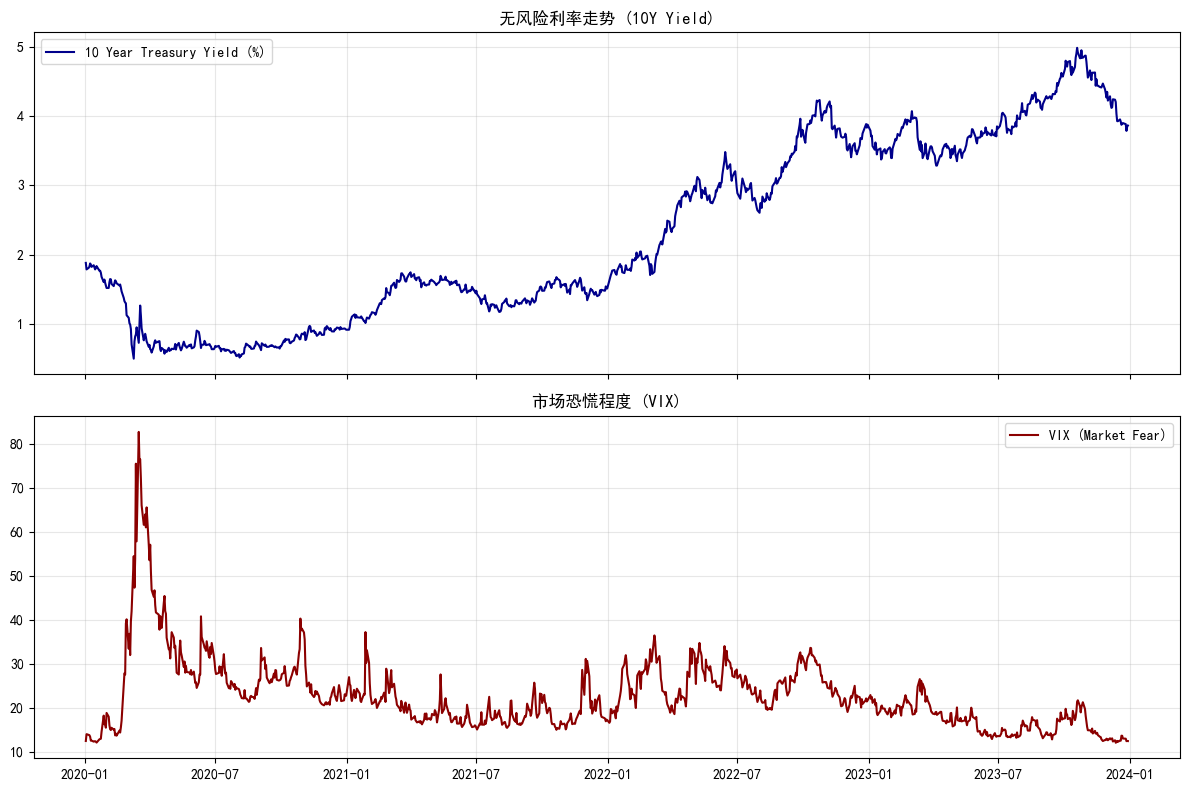

宏观数据获取成功！这些数据通常作为因子的环境‘过滤器’使用。


In [8]:
# 获取 10 年期美债收益率和 VIX 数据
macro_data = yf.download(['^TNX', '^VIX'], start='2020-01-01', end='2024-01-01', progress=False)['Close']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(macro_data.index, macro_data['^TNX'], color='darkblue', label='10 Year Treasury Yield (%)')
ax1.set_title("无风险利率走势 (10Y Yield)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(macro_data.index, macro_data['^VIX'], color='darkred', label='VIX (Market Fear)')
ax2.set_title("市场恐慌程度 (VIX)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("宏观数据获取成功！这些数据通常作为因子的环境‘过滤器’使用。")

## 🎯 练习

1. 下载你感兴趣的 5 只股票，绘制标准化收益对比图。
2. 使用 `adata` 或者 `yfinance` 获取单只股票数据并保存为 CSV。
3. 获取黄金期货（`GC=F`）数据，观察它在 2020 年市场大恐慌期间的表现。

---
**下一节** → `02_data_cleaning.ipynb`
